<a href="https://colab.research.google.com/github/FareedaAbdelaal/ML-55-9988/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving GUC_2350_68_65247_2026-02-26T09_19_37 (1).zip to GUC_2350_68_65247_2026-02-26T09_19_37 (1).zip


In [2]:
import zipfile
import os

zip_file_name = "GUC_2350_68_65247_2026-02-26T09_19_37 (1).zip"  # replace with your file name

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("unzipped_folder")  # folder name

print("Unzipped successfully!")

Unzipped successfully!


In [68]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_iris

from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import product

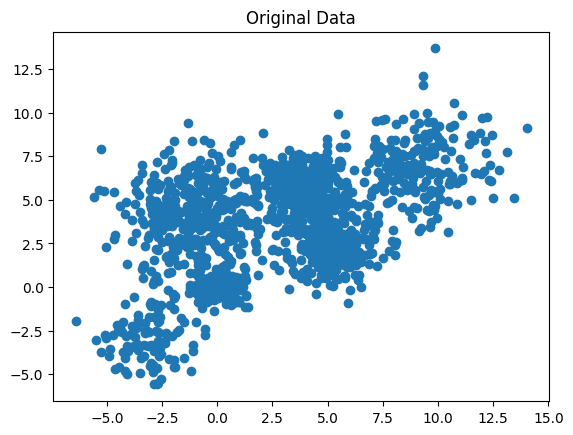

In [69]:
#Multi Blob Dataset
#Generate Dataset
n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]

X, _ = make_blobs(
    n_samples=[100,150,300,400,300,200],
    centers=centers,
    cluster_std=[1.3,0.6,1.2,1.7,0.9,1.7],
    random_state=42
)

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()


We generated a synthetic dataset with 6 clusters. This will help us evaluate how well each clustering algorithm performs.

In [70]:
# K-means
#Differenet Values
Ks = range(2, 11)
distortions = []
sil_scores = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)

    distortions.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))


We tested multiple values of K to determine the optimal number of clusters using both inertia (Elbow method) and silhouette score.

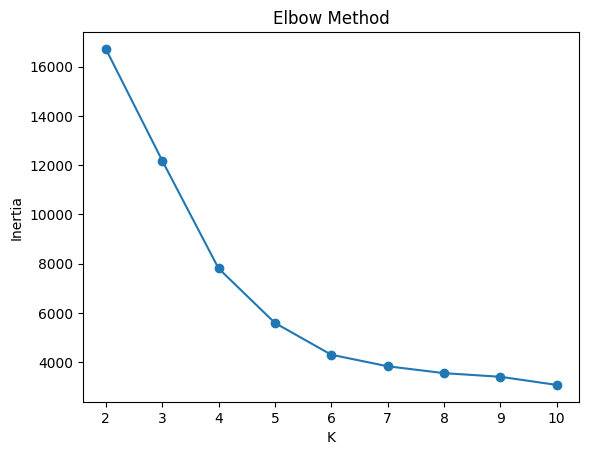

In [71]:
#Elbow Method
plt.plot(Ks, distortions, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()


The elbow point appears around K=5 to K=6, where the reduction in inertia starts to slow down.
This suggests that the optimal number of clusters lies in this range, which aligns with the true number of clusters in the dataset.

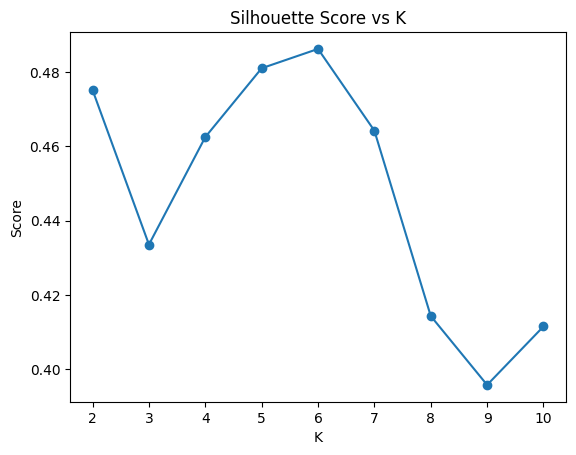

In [72]:
# Silhouette
plt.plot(Ks, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()


The silhouette score reaches its maximum at K=6 (~0.486), indicating that this value provides the best cluster separation.
This confirms that K=6 is the optimal choice for this dataset.

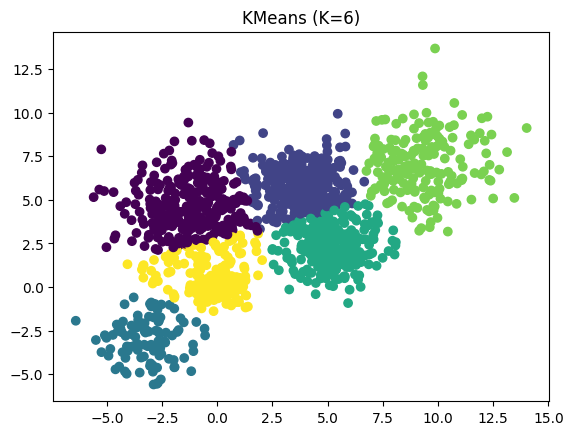

0.4862240839323367


In [73]:
best_k = Ks[np.argmax(sil_scores)]

model = KMeans(n_clusters=best_k, random_state=42)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title(f"KMeans (K={best_k})")
plt.show()

kmeans_score = silhouette_score(X, labels)
print(kmeans_score)


KMeans with K=6 achieved a silhouette score (~0.486), indicating good cluster separation.
The algorithm successfully identified most of the natural clusters, although slight overlap exists between some groups due to varying densities and variances.

Overall, KMeans performs well on this dataset and effectively captures the underlying structure.

In [74]:
# Hierarchical Clustering

# Parameter Search

affinities = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average']

best_score = -1

for affinity, linkage_method in product(affinities, linkages):
    try:
        model = AgglomerativeClustering(
            n_clusters=6,
            metric=affinity,
            linkage=linkage_method
        )
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)

        if score > best_score:
            best_score = score
            best_params = (affinity, linkage_method)
    except:
        pass

print("Best Params:", best_params)
print("Best Score:", best_score)

Best Params: ('euclidean', 'ward')
Best Score: 0.4686938472105883



The best configuration for hierarchical clustering was (euclidean, ward) with a silhouette score (~0.469).
This performance is slightly lower than KMeans but still indicates good cluster separation.

Hierarchical clustering was able to capture the general structure of the data, but it is slightly less effective than KMeans for this dataset.

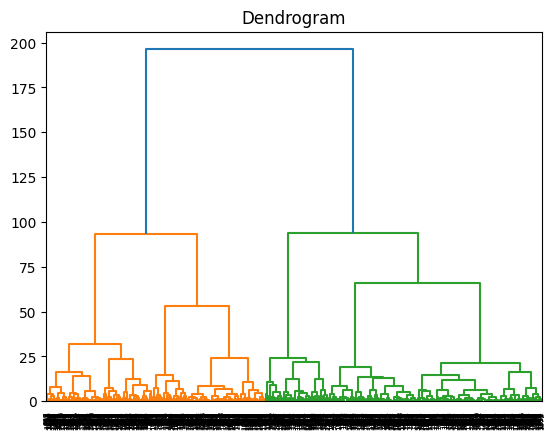

In [75]:
# Dendrogram
Z = linkage(X, method='ward')
dendrogram(Z)
plt.title("Dendrogram")
plt.show()


The dendrogram shows hierarchical merging of clusters and supports the existence of multiple cluster groupings.

In [76]:
# DBSCAN
# Parameter Search

best_score = -1

for eps in np.arange(0.1, 3, 0.2):
    for min_samples in range(5, 25):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)

        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)

            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

print("Best Params:", best_params)
print("Best Score:", best_score)


Best Params: (np.float64(2.1000000000000005), 6)
Best Score: 0.4685207355522043



DBSCAN achieved a silhouette score (~0.468), which is very close to KMeans.
This indicates that DBSCAN was also effective in identifying the clusters without requiring a predefined number of clusters.

This shows that the dataset contains well separated dense regions, making it suitable for density based clustering.

In [77]:
# IRIS Dataset
# Loading Dataset
# Not Scaled
iris = load_iris()
X = iris.data
y = iris.target


The Iris dataset was loaded. It contains 4 numerical features and 3 classes.

In [78]:
# K-Means (Not Scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print("KMeans Score (no scaling):", score)

KMeans Score (no scaling): 0.551191604619592



KMeans without scaling achieved a silhouette score (~0.551), indicating moderate clustering performance.
This suggests that the dataset already has a structure that can be reasonably captured without preprocessing.

In [79]:
#Hierarchical

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

score = silhouette_score(X, labels)
print("Hierarchical Score (no scaling):", score)

Hierarchical Score (no scaling): 0.5543236611296419



Hierarchical clustering without scaling achieved a silhouette score (~0.554), slightly outperforming KMeans.
This indicates that hierarchical methods can effectively capture relationships in the original feature space.

In [80]:
# DBSCAN (Not Scaled)
model = DBSCAN(eps=0.5, min_samples=5)
labels = model.fit_predict(X)

if len(set(labels)) > 1:
    score = silhouette_score(X, labels)
    print("DBSCAN Score (no scaling):", score)

DBSCAN Score (no scaling): 0.48603419703456857



DBSCAN achieved a silhouette score (~0.486), which is lower than both KMeans and hierarchical clustering.
This suggests that density based clustering is less suitable for this dataset without parameter tuning.

In [81]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Features were standardized to have equal contribution.

In [82]:
#K-Means (Scaled)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

score_scaled_kmeans = silhouette_score(X_scaled, labels)
print("KMeans Score (scaled):", score_scaled_kmeans)

KMeans Score (scaled): 0.4798814508199817



After scaling, KMeans achieved a lower silhouette score (~0.480), indicating a decrease in clustering performance.
This suggests that scaling disrupted the natural structure of the dataset.

In [83]:
# Hierarchical (Scaled)
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X_scaled)

score_scaled_hier = silhouette_score(X_scaled, labels)
print("Hierarchical Score (scaled):", score_scaled_hier)

Hierarchical Score (scaled): 0.4466890410285909



Hierarchical clustering performance decreased after scaling (~0.447), confirming that scaling negatively affected clustering quality.

In [84]:
# DBSCAN (Scaled)
model = DBSCAN(eps=0.5, min_samples=5)
labels = model.fit_predict(X_scaled)

if len(set(labels)) > 1:
    score_scaled_dbscan = silhouette_score(X_scaled, labels)
    print("DBSCAN Score (scaled):", score_scaled_dbscan)

DBSCAN Score (scaled): 0.35651648142700726



DBSCAN performance dropped significantly after scaling (~0.357), indicating that scaling made density based clustering less effective.

In [61]:
from google.colab import files
uploaded = files.upload()

Saving Customer data.csv to Customer data (1).csv


In [62]:
# Custoer Dataset
#Load Dataset
df = pd.read_csv('/content/Customer data.csv')
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1



The customer dataset was loaded for clustering analysis.

In [63]:
# Preprocessing
df = df.select_dtypes(include=[np.number])
df.dropna(inplace=True)


Only numerical features were kept and missing values removed to prepare data for clustering.

In [64]:
#Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

Data was scaled to ensure fair distance calculations.

In [65]:
#K-Means
model = KMeans(n_clusters=3, random_state=42)
labels = model.fit_predict(df_scaled)

print(silhouette_score(df_scaled, labels))

0.24437057324500533



KMeans achieved a silhouette score (~0.244), indicating weak cluster separation.
This suggests that customer segments are not clearly separable using KMeans.
However, it still performed better than the other clustering methods on this dataset.

In [66]:
# Hierarchical
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(df_scaled)

print(silhouette_score(df_scaled, labels))

0.18063421720096534



Hierarchical clustering achieved a lower silhouette score (~0.181), indicating poorer cluster quality compared to KMeans.
This suggests that hierarchical methods struggled to capture meaningful customer segments in this dataset.

In [67]:
# DBSCAN
model = DBSCAN(eps=0.5, min_samples=5)
labels = model.fit_predict(df_scaled)

if len(set(labels)) > 1:
    print(silhouette_score(df_scaled, labels))

0.09613494822404076



DBSCAN achieved the lowest silhouette score (~0.096), indicating very weak clustering performance.
This suggests that the dataset does not contain well defined density based clusters, or that the chosen parameters were not optimal.

Conclusion:

For the Multi-Blob dataset:
- KMeans achieved the best performance (~0.486), correctly identifying the true number of clusters.
- DBSCAN performed almost equally well (~0.468), showing its strength in detecting dense regions.
- Hierarchical clustering also performed well (~0.469) but slightly below KMeans.

For the Iris dataset:
- Moderate clustering performance was observed without scaling (around ~0.55).
- Scaling reduced performance across all algorithms, indicating that the dataset was already well structured.
- Hierarchical clustering slightly outperformed KMeans in the unscaled case.

For the Customer dataset:
- Clustering performance was generally low, indicating weak natural groupings.
- KMeans performed best among the three methods, followed by hierarchical clustering, while DBSCAN performed the worst.

Overall:
- KMeans is the most consistent and reliable algorithm across different datasets.
- DBSCAN performs very well when clusters are dense and well separated, but struggles with real world data.
- Hierarchical clustering provides competitive performance but does not consistently outperform KMeans.

Conclusion:
Clustering performance strongly depends on the structure of the dataset.
Well defined datasets produce strong clustering results, while real world datasets tend to have overlapping patterns that reduce clustering effectiveness.